<a href="https://colab.research.google.com/github/20020608/Notepad/blob/main/Elbow_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:

from google.colab import files
import pandas as pd


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans

In [14]:
uploaded =files.upload()
df =pd.read_csv('Countries_exercise.csv')
df.head()

Saving Countries_exercise.csv to Countries_exercise (9).csv


,name,Longitude,Latitude
0,Aruba,-69.982677,12.520880
1,Afghanistan,66.004734,33.835231
2,Angola,17.537368,-12.293361
3,Anguilla,-63.064989,18.223959
4,Albania,20.049834,41.142450


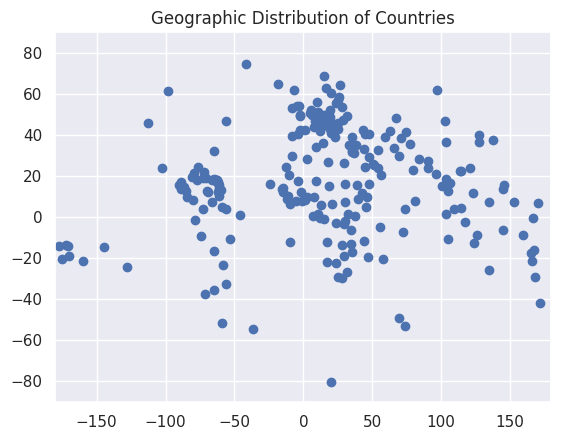

In [17]:
plt.scatter(df['Longitude'], df['Latitude'])

plt.xlim(-180,180)
plt.ylim(-90, 90)
plt.title('Geographic Distribution of Countries')
plt.show()

In [18]:
x=df.iloc[:,1:3]
x.head()

,Longitude,Latitude
0,-69.982677,12.520880
1,66.004734,33.835231
2,17.537368,-12.293361
3,-63.064989,18.223959
4,20.049834,41.142450


In [19]:
kmeans=KMeans(4)
kmeans.fit(x)


KMeans(n_clusters=4)

In [20]:
identified_clusters=kmeans.fit_predict(x)
identified_clusters

array([1, 0, 3, 1, 0, 0, 0, 0, 1, 0, 1, 3, 2, 3, 1, 2, 0, 0, 3, 0, 3, 3,
       2, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 2, 3, 3, 0, 1, 2, 3, 3,
       3, 3, 1, 1, 3, 3, 1, 1, 1, 1, 0, 0, 0, 0, 3, 1, 0, 1, 0, 1, 0, 3,
       0, 0, 3, 0, 2, 1, 0, 0, 2, 3, 0, 0, 0, 3, 3, 3, 3, 3, 0, 1, 0, 1,
       2, 1, 2, 3, 1, 0, 1, 0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       2, 2, 0, 3, 0, 2, 1, 1, 2, 0, 0, 2, 0, 3, 0, 1, 0, 2, 3, 0, 0, 0,
       2, 1, 0, 0, 0, 3, 2, 1, 2, 0, 3, 0, 2, 0, 2, 2, 3, 3, 1, 3, 3, 2,
       3, 2, 3, 2, 3, 1, 1, 0, 0, 2, 2, 2, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1,
       2, 0, 1, 0, 1, 0, 0, 2, 3, 0, 0, 3, 3, 3, 2, 3, 3, 2, 3, 1, 0, 3,
       3, 1, 0, 3, 1, 0, 0, 0, 3, 1, 3, 0, 1, 3, 3, 2, 0, 0, 2, 1, 1, 0,
       0, 2, 3, 3, 0, 1, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 1, 3, 3, 3, 3],
      dtype=int32)

In [22]:
data_with_clusters=df.copy()
data_with_clusters = df.copy()
data_with_clusters['Cluster'] = identified_clusters
data_with_clusters

,name,Longitude,Latitude,Cluster
0,Aruba,-69.982677,12.520880,1
1,Afghanistan,66.004734,33.835231,0
2,Angola,17.537368,-12.293361,3
3,Anguilla,-63.064989,18.223959,1
4,Albania,20.049834,41.142450,0
...,...,...,...,...
236,Samoa,-172.164851,-13.753243,1
237,Yemen,47.586762,15.909280,3
238,South Africa,25.083901,-29.000341,3
239,Zambia,27.774759,-13.458242,3


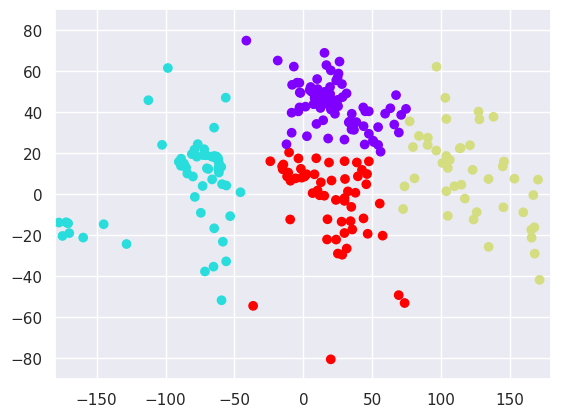

In [23]:
plt.scatter(df['Longitude'], df['Latitude'], c=data_with_clusters['Cluster'], cmap = 'rainbow')
plt.xlim(-180,180)
plt.ylim(-90, 90)
plt.show()

In [25]:
kmeans.inertia_

260086.6455332171

In [26]:
wcss=[]
for i in range(1,11):
  kmeans=KMeans(i)
  kmeans.fit(x)
  wcss_iter=kmeans.inertia_
  wcss.append(wcss_iter)

Text(0, 0.5, 'Within-cluster Sum of Squares')

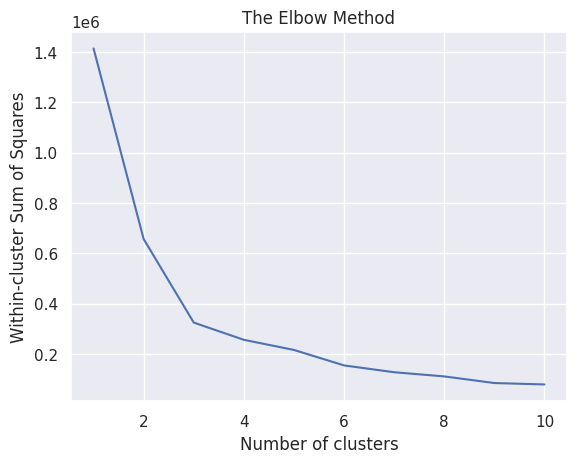

In [27]:
number_clusters = range(1,11)
plt.plot(number_clusters, wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Within-cluster Sum of Squares')